In [10]:
import pandas as pd
import matplotlib.pyplot as plt

flights = pd.read_csv('flights.csv')
airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')

C:\Users\dieos\AppData\Local\Temp\ipykernel_21268\3103187146.py:4: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('flights.csv')


## Результат 1 

Большинство рейсов выполняются без задержки или с небольшой задержкой до 30 минут. Однако заметная часть рейсов попадает в категории серьёзных задержек, особенно свыше 60 минут. Хотим найти какую часть рейсов составляют различные задержки

Виды задержки
Без задержки       3607308
До 30 мин          1487248
Больше 60 мин       324171
От 31 до 60 мин     314199
Name: count, dtype: int64


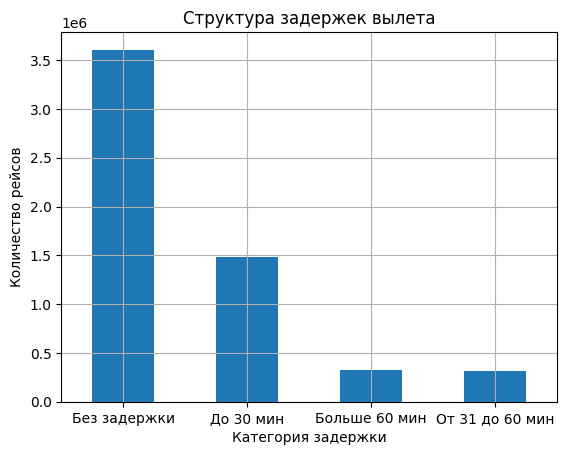

In [29]:
flights['DEPARTURE_DELAY'] = pd.to_numeric(flights['DEPARTURE_DELAY'])
flights = flights.dropna(subset=['DEPARTURE_DELAY'])

def group_delay(x):
    if x <= 0:
        return 'Без задержки'
    elif x <= 30:
        return 'До 30 мин'
    elif x <= 60:
        return 'От 31 до 60 мин'
    else:
        return 'Больше 60 мин'

flights['Виды задержки'] = flights['DEPARTURE_DELAY'].apply(group_delay)

delay_counts = flights['Виды задержки'].value_counts()

print(delay_counts)

delay_counts.plot(kind='bar')
plt.grid()
plt.title('Структура задержек вылета')
plt.xlabel('Категория задержки')
plt.ylabel('Количество рейсов')
plt.xticks(rotation=0)
plt.show()

Большая часть рейсов выполняется без задержки или с небольшой задержкой.  
При этом есть заметная группа рейсов с серьёзными задержками, и именно она создаёт основную проблему.

## Результат 2 

Теперь посмотрим, зависят ли задержки от дня недели.  
Это поможет понять, есть ли дни с особенно большой нагрузкой на систему.


День недели
Monday       10.871775
Tuesday       9.164522
Wednesday     8.645277
Thursday      9.956913
Friday        9.429768
Saturday      7.827416
Sunday        9.402856
Name: DEPARTURE_DELAY, dtype: float64


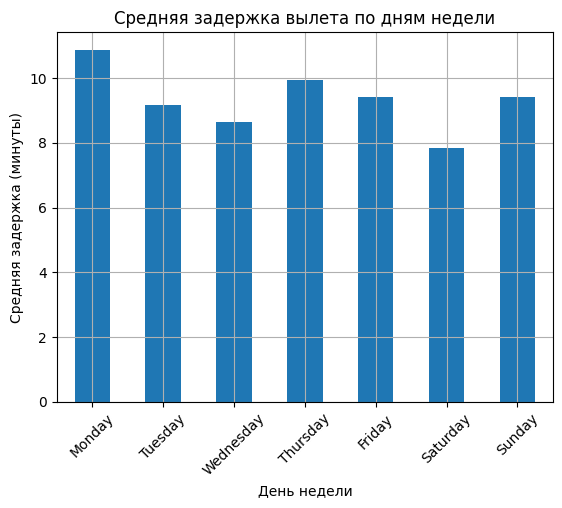

In [30]:
flights['DATE'] = pd.to_datetime(flights[['YEAR', 'MONTH', 'DAY']])
flights['День недели'] = flights['DATE'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_delay = flights.groupby('День недели')['DEPARTURE_DELAY'].mean()
day_delay = day_delay.reindex(days_order)

print(day_delay)

day_delay.plot(kind='bar')
plt.grid()
plt.title('Средняя задержка вылета по дням недели')
plt.xlabel('День недели')
plt.ylabel('Средняя задержка (минуты)')
plt.xticks(rotation=45)
plt.show()

Задержки распределены по дням недели неравномерно.  
Есть дни, когда средняя задержка выше, чем в остальные, значит нагрузка на рейсы в течение недели различается.(например в понедельник)

## Результат 3


Далее сравним авиакомпании.  
Это позволит понять, есть ли перевозчики, у которых рейсы в среднем задерживаются сильнее остальных.

                       AIRLINE_y  DEPARTURE_DELAY
8               Spirit Air Lines        15.944766
10         United Air Lines Inc.        14.435441
5         Frontier Airlines Inc.        13.350858
2                JetBlue Airways        11.514353
13        Southwest Airlines Co.        10.581986
7   American Eagle Airlines Inc.        10.125188
12                Virgin America         9.022595
0         American Airlines Inc.         8.900856
4    Atlantic Southeast Airlines         8.715934
9          Skywest Airlines Inc.         7.801104


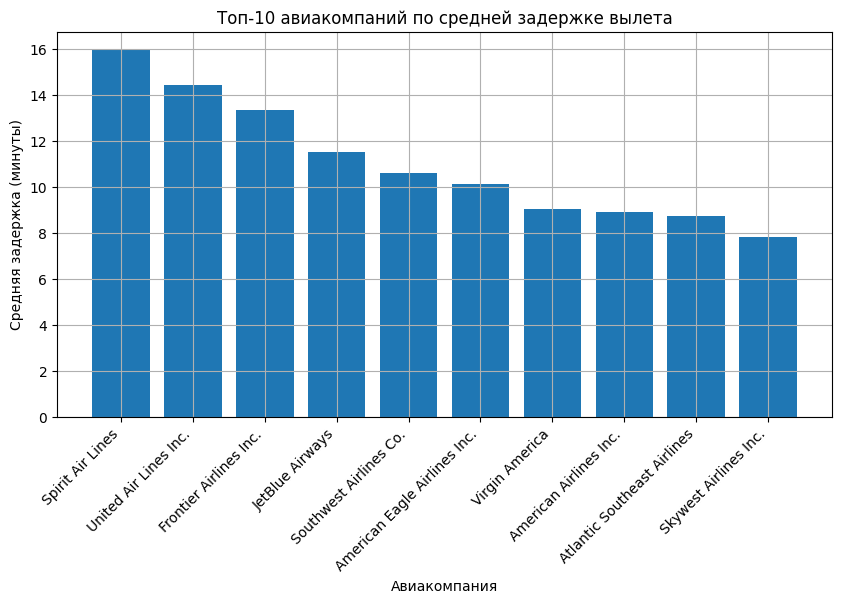

In [34]:
company_delay = flights.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().reset_index()

company_delay = company_delay.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE')

company_delay = company_delay.sort_values('DEPARTURE_DELAY', ascending=False)

print(company_delay[['AIRLINE_y', 'DEPARTURE_DELAY']].head(10))

top_companies = company_delay.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_companies['AIRLINE_y'], top_companies['DEPARTURE_DELAY'])
plt.title('Топ-10 авиакомпаний по средней задержке вылета')
plt.xlabel('Авиакомпания')
plt.ylabel('Средняя задержка (минуты)')
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.show()


Некоторые авиакомпании заметно хуже других по средней задержке вылета.  
Это значит, что проблема связана не только с аэропортами и погодой, но и с работой конкретных перевозчиков.

## Результат 4

Теперь посмотрим на аэропорты вылета.  
Это поможет найти узкие места в системе, где задержки появляются особенно часто.

                                               AIRPORT                  CITY  \
154                                 Wilmington Airport            Wilmington   
219                          Martha's Vineyard Airport      Marthas Vineyard   
147                       Barnstable Municipal Airport               Hyannis   
293                         St. Cloud Regional Airport              St Cloud   
231  Southwest Oregon Regional Airport (North Bend ...            North Bend   
19                         Aspen-Pitkin County Airport                 Aspen   
57      Del Norte County Airport (Jack McNamara Field)         Crescent City   
133                                   Gustavus Airport              Gustavus   
40   Jack Brooks Regional Airport (Southeast Texas ...  Beaumont/Port Arthur   
137                         Guam International Airport                 Agana   

     DEPARTURE_DELAY  
154        29.391753  
219        25.907317  
147        23.182927  
293        18.692308  
231 

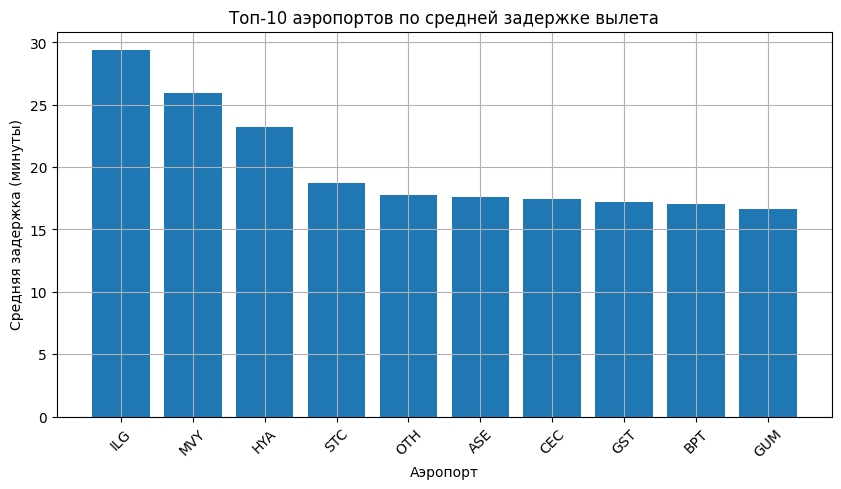

In [33]:
airport_delay = flights.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().reset_index()

airport_delay = airport_delay.merge(airports, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE')

airport_delay = airport_delay.sort_values('DEPARTURE_DELAY', ascending=False)

print(airport_delay[['AIRPORT', 'CITY', 'DEPARTURE_DELAY']].head(10))
    
top_airports = airport_delay.head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_airports['ORIGIN_AIRPORT'], top_airports['DEPARTURE_DELAY'])
plt.title('Топ-10 аэропортов по средней задержке вылета')
plt.xlabel('Аэропорт')
plt.ylabel('Средняя задержка (минуты)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

Есть аэропорты, где средняя задержка вылета заметно выше.  
Именно в этих точках система работает хуже всего, и они являются проблемными узлами.


## Результат 5

В конце посмотрим не на отдельные аэропорты, а на маршруты.  
Возможно, проблема возникает на конкретных направлениях, а не просто в отдельных точках.

            Маршрут  DEPARTURE_DELAY
5918      IAD - TTN       341.000000
8429      SWF - PBI       256.000000
7744      RDU - IND       209.000000
4800      CRP - HRL       206.000000
8145      SGF - HYS       206.000000
7766      RIC - CAE       190.000000
5637      FSD - LNK       166.000000
8430      SWF - RSW       153.000000
6921      MSO - BTM       151.000000
312   10581 - 12953       147.333333


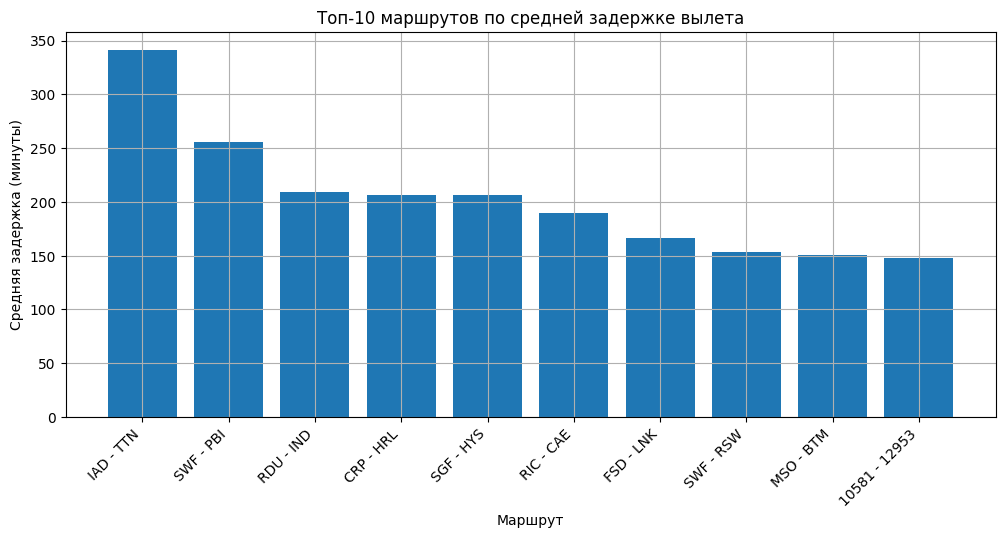

In [35]:
flights['Маршрут'] = flights['ORIGIN_AIRPORT'].astype(str) + ' - ' + flights['DESTINATION_AIRPORT'].astype(str)

route_delay = flights.groupby('Маршрут')['DEPARTURE_DELAY'].mean().reset_index()

route_delay = route_delay.sort_values('DEPARTURE_DELAY', ascending=False)

print(route_delay.head(10))

top_routes = route_delay.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_routes['Маршрут'], top_routes['DEPARTURE_DELAY'])
plt.title('Топ-10 маршрутов по средней задержке вылета')
plt.xlabel('Маршрут')
plt.ylabel('Средняя задержка (минуты)')
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.show()

Некоторые маршруты оказываются особенно проблемными по задержкам.  
Это показывает, что причины задержек могут быть связаны не только с авиакомпанией или аэропортом, но и с конкретным направлением полёта.